# **Project 45: Expedia Hotel Recommendation System**

***pandas*** : *For data manipulation and analysis, particularly with data structures like DataFrames.*

***numpy*** : *For numerical computations and operations on arrays.*

***seaborn*** : *For creating attractive and informative statistical visualizations.*

***matplotlib.pyplot*** : *For general-purpose plotting and visualizing data in graphs and charts.*

***warnings*** : *To handle and suppress warnings during code execution.*

# **Data Loading**

**Importing these libraries for Data Loading, Data Cleaning and Data Visualization.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

**The line warnings.simplefilter("ignore") is used to suppress warnings during the execution of your code.**

In [3]:
warnings.simplefilter("ignore")

**I've uploaded my 3 GB data file to Google Drive and I'm accessing it using the following commands.**

In [3]:
# from google.colab import drive
# drive.mount("/content/drive")

Mounted at /content/drive


**The command !pip install s3fs is used to install the s3fs library in your environment.**

In [ ]:
!pip install s3fs

**Read CSV in Chunks: The code reads a large CSV file from an S3 bucket in chunks of 2,000,000 rows, using pd.read_csv() with the chunksize parameter.**

**Processing Chunks: It processes each chunk sequentially, printing the chunk number being processed.**

**Store Chunks: Each processed chunk is appended to a list (chunk_list) for further processing or analysis.**

In [ ]:
s3_uri = 's3://epedia-hotel-bucket/Expedia Hotel.csv'
chunk_size = 2000000

chunk_list = []

for i, chunk in enumerate(pd.read_csv(s3_uri, storage_options={'anon': True}, chunksize=chunk_size)):
    print(f'Processing Chunk {i + 1}')
    chunk_list.append(chunk)

Processing Chunk 1
Processing Chunk 2
Processing Chunk 3
Processing Chunk 4
Processing Chunk 5
Processing Chunk 6
Processing Chunk 7
Processing Chunk 8
Processing Chunk 9
Processing Chunk 10
Processing Chunk 11
Processing Chunk 12
Processing Chunk 13
Processing Chunk 14
Processing Chunk 15
Processing Chunk 16
Processing Chunk 17
Processing Chunk 18
Processing Chunk 19


**Download File: The code downloads a file from a specified URL using the requests library, streaming the content to handle large files efficiently.**

**Progress Bar: It uses tqdm to display a progress bar showing the download progress, updating as chunks of data are written to a local file.**

**Save File: The file is saved locally with the specified filename, and a confirmation message is printed once the download is complete.**

In [ ]:
import requests
from tqdm import tqdm

file_url = 'https://epedia-hotel-bucket.s3.amazonaws.com/Expedia Hotel.csv'
local_filename = 'Expedia Hotel.csv'

response = requests.get(file_url, stream=True)

total_size = int(response.headers.get('content-length', 0))

with open(local_filename, 'wb') as file, tqdm(
    desc=f"Downloading {local_filename}",
    total=total_size,
    unit='B',
    unit_scale=True,
    unit_divisor=1024,
) as bar:
    for data in response.iter_content(chunk_size=1024):
        file.write(data)
        bar.update(len(data))

print(f"File Downloaded And Saved As {local_filename}")

File Downloaded And Saved As Expedia Hotel.csv


**Read CSV in Chunks: The code reads a large CSV file in chunks of 10,000,000 rows using pd.read_csv() with the chunksize parameter.**

**Progress Bar: It uses tqdm to display a progress bar that updates based on the number of rows processed, showing the progress of loading the data.**

**Store Chunks: Each chunk is appended to a list (chunks) for further processing after loading the entire file.**

In [ ]:
from tqdm import tqdm

file_path = 'Expedia Hotel.csv'

chunk_size = 10000000

chunks = []

with tqdm(total=sum(1 for _ in open(file_path, 'r')), desc="Loading Data") as pbar:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        chunks.append(chunk)
        pbar.update(chunk.shape[0])

Loading Data: 100%|█████████▉| 37670293/37670294 [01:06<00:00, 565120.36it/s]


**The complete DataFrame is loaded and stored in the variable "df" for further processing.**

In [4]:
# df = pd.read_csv("/content/drive/MyDrive/Expedia Hotel.csv")

**pd.read_csv("Expedia Hotel.csv"): Reads the CSV file Expedia Hotel.csv into a Pandas DataFrame df for further analysis.**

**pd.set_option("display.max_columns", None): Ensures that when the DataFrame is displayed, all columns will be shown (no truncation).**

**pd.set_option("display.max_rows", None): Ensures that all rows of the DataFrame will be displayed without truncation.**

In [ ]:
df = pd.concat(chunks, ignore_index=True)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

**df.head(5): Displays the first five rows of the DataFrame to get a preview of the dataset.**

In [9]:
df.head(5)

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,2014-08-11 07:46:59,2,3,66,348,48862,2234.2641,12,0,1,...,0,1,8250,1,0,3,2,50,628,1
1,2014-08-11 08:22:12,2,3,66,348,48862,2234.2641,12,0,1,...,0,1,8250,1,1,1,2,50,628,1
2,2014-08-11 08:24:33,2,3,66,348,48862,2234.2641,12,0,0,...,0,1,8250,1,0,1,2,50,628,1
3,2014-08-09 18:05:16,2,3,66,442,35390,913.1932,93,0,0,...,0,1,14984,1,0,1,2,50,1457,80
4,2014-08-09 18:08:18,2,3,66,442,35390,913.6259,93,0,0,...,0,1,14984,1,0,1,2,50,1457,21


**The number of non-null entries for each column.**

**Data types of each column.**

**The total number of entries in the DataFrame.​**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37670293 entries, 0 to 37670292
Data columns (total 24 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   date_time                  object 
 1   site_name                  int64  
 2   posa_continent             int64  
 3   user_location_country      int64  
 4   user_location_region       int64  
 5   user_location_city         int64  
 6   orig_destination_distance  float64
 7   user_id                    int64  
 8   is_mobile                  int64  
 9   is_package                 int64  
 10  channel                    int64  
 11  srch_ci                    object 
 12  srch_co                    object 
 13  srch_adults_cnt            int64  
 14  srch_children_cnt          int64  
 15  srch_rm_cnt                int64  
 16  srch_destination_id        int64  
 17  srch_destination_type_id   int64  
 18  is_booking                 int64  
 19  cnt                        int64  
 20  

**df.shape returns the dimensions of the DataFrame df, showing the number of rows and columns as a tuple (rows, columns).**

In [7]:
df.shape

(37670293, 24)

**df.isnull().sum() returns the count of missing (NaN) values for each column in the DataFrame df.**

In [8]:
df.isnull().sum()

,0
date_time,0
site_name,0
posa_continent,0
user_location_country,0
user_location_region,0
user_location_city,0
orig_destination_distance,13525001
user_id,0
is_mobile,0
is_package,0


**This code calculates and displays the total and percentage of missing values for each column in the DataFrame df, sorted in descending order of total missing values.**

In [5]:
total=df.isnull().sum().sort_values(ascending=False)
percent=(df.isnull().sum()/df['hotel_cluster'].count()).sort_values(ascending=False)
missing_data=pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
orig_destination_distance,13525001,0.359036
srch_co,47084,0.001250
srch_ci,47083,0.001250
date_time,0,0.000000
user_location_country,0,0.000000
user_location_region,0,0.000000
posa_continent,0,0.000000
site_name,0,0.000000
user_id,0,0.000000
user_location_city,0,0.000000


**This code fills missing values in the orig_destination_distance column with the mean value of that column, modifying the DataFrame df in place.**

In [6]:
df['orig_destination_distance'].fillna(df['orig_destination_distance'].mean(), inplace=True)

# **Data Visualization**

**This code creates a count plot using Seaborn to visualize the distribution of the is_mobile column in the DataFrame df, with the plot size set to 13x8 inches and using the "Set1" color palette.**

**In this graph, we create a count plot for the is_mobile variable to see the counts based on 0 and 1, where 0 represents non-mobile and 1 represents mobile.**

<Axes: xlabel='is_mobile', ylabel='count'>

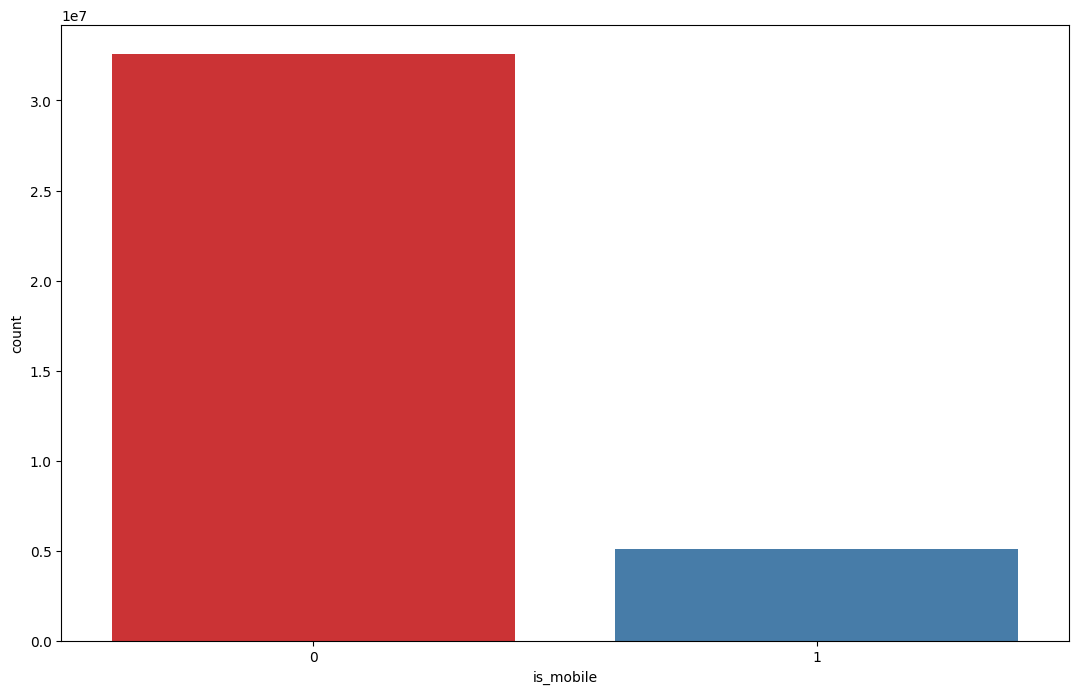

In [11]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 8)
sns.countplot(x='is_mobile',data=df, order=[0,1],ax=ax, palette="Set1")

**This code creates a count plot using Seaborn to visualize the distribution of the is_package column in the DataFrame df, with the plot size set to 13x8 inches and using the "Set1" color palette.**

**In this graph, we create a count plot for the is_package variable to see the counts based on 0 and 1, where 0 represents not a package and 1 represents a package.**

<Axes: xlabel='is_package', ylabel='count'>

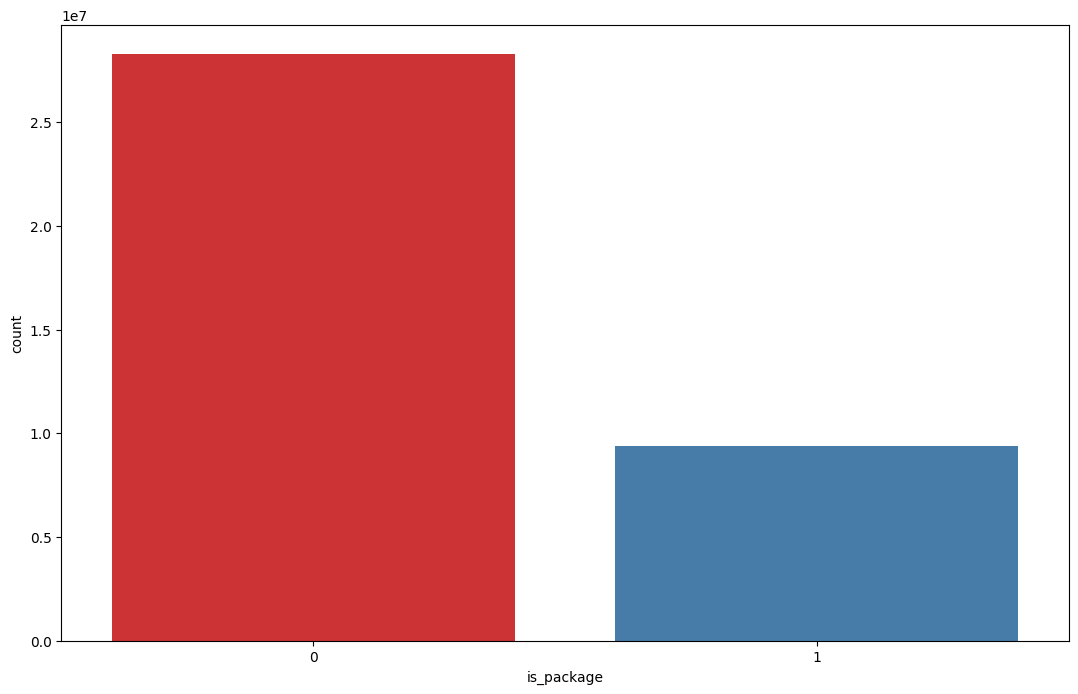

In [12]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 8)
sns.countplot(x='is_package',data=df, order=[0,1], ax=ax, palette="Set1")

**This code generates a count plot with Seaborn to visualize the distribution of the posa_continent column in the DataFrame df, with the plot size set to 13x8 inches, using the "Set1" color palette, and ordered by the specified continent codes [0, 1, 2, 3, 4].**

**In a separate graph, we create a count plot for the posa_continent variable to see the counts based on its categories. We use the order [0, 2, 3, 4, 5, 6] to display the categories.**

<Axes: xlabel='posa_continent', ylabel='count'>

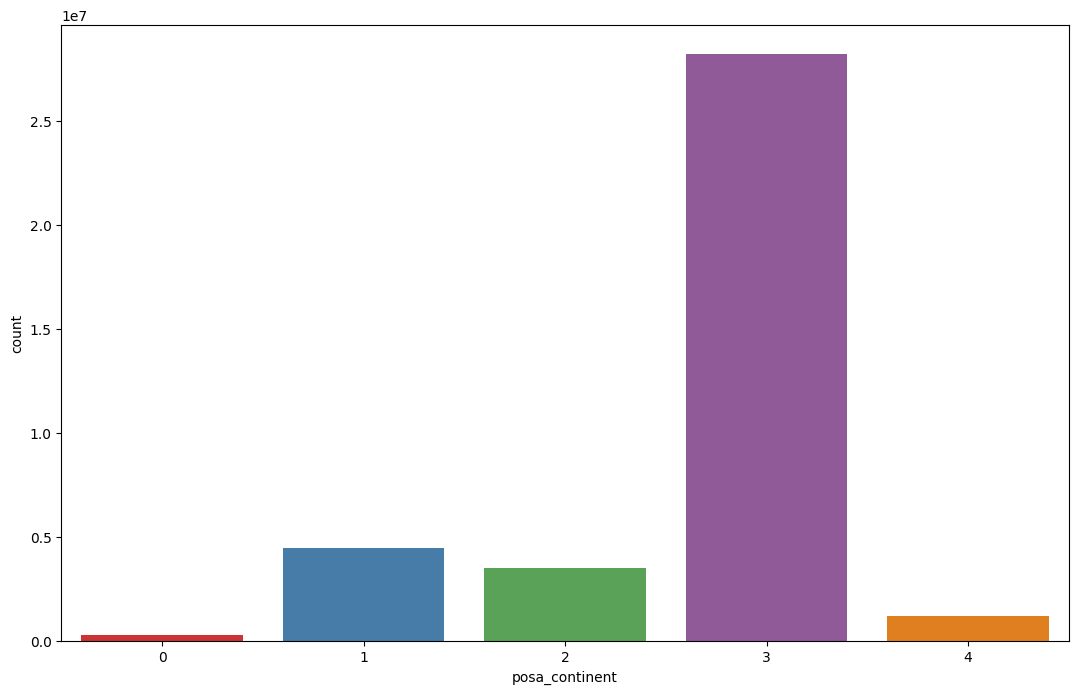

In [13]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 8)
sns.countplot(x='posa_continent', data=df, order=[0,1,2,3,4],ax=ax, palette="Set1")

**This code creates a count plot using Seaborn to show the distribution of the hotel_continent column in the DataFrame df, with the plot size set to 13x8 inches, using the "Set1" color palette, and ordered by the specified continent codes [0, 2, 3, 4, 5, 6].**

**In another graph, we create a count plot for the hotel_continent variable to see the counts based on its categories. We use the order [0, 2, 3, 4, 5, 6] to display the categories.**

<Axes: xlabel='hotel_continent', ylabel='count'>

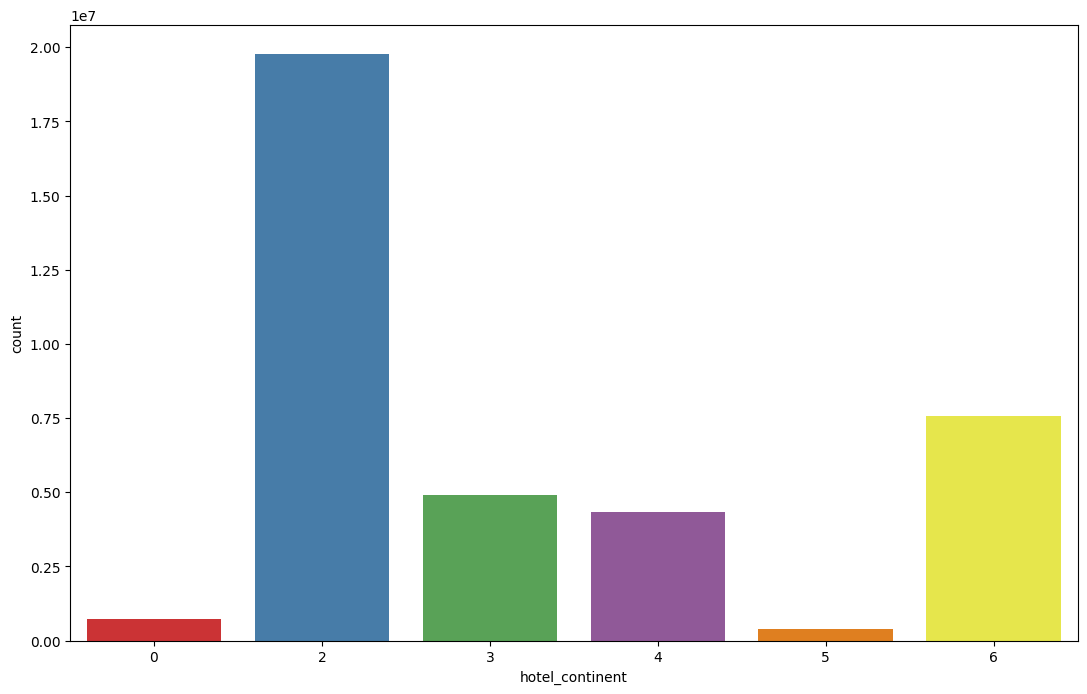

In [14]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 8)
sns.countplot(x='hotel_continent', data=df, order=[0,2,3,4,5,6],ax=ax, palette="Set1")

**This code generates a count plot using Seaborn to visualize the distribution of hotel_continent in the DataFrame df, with different colors representing posa_continent values, and the plot size set to 13x8 inches.**

**In this graph, we display the count for hotel_continent with posa_continent used as the hue to show how the counts of hotel_continent are distributed across different categories of posa_continent.**

<Axes: xlabel='hotel_continent', ylabel='count'>

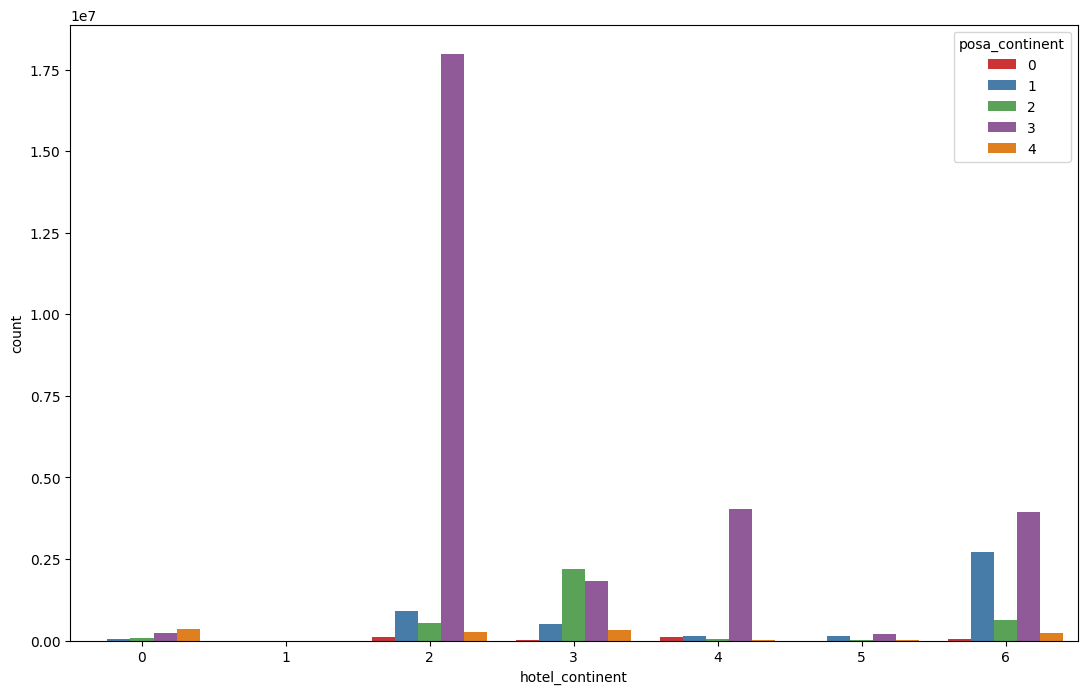

In [15]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 8)
sns.countplot(x='hotel_continent', hue='posa_continent', data=df, palette="Set1")

**This code creates a count plot using Seaborn to visualize the distribution of posa_continent in the DataFrame df, with different colors representing the is_mobile values, and uses the "Set1" color palette. The plot size is set to 13x8 inches.**

**In this graph, we visualize the count plot for posa_continent, with is_mobile used as the hue to distinguish between mobile and non-mobile categories.**

<Axes: xlabel='posa_continent', ylabel='count'>

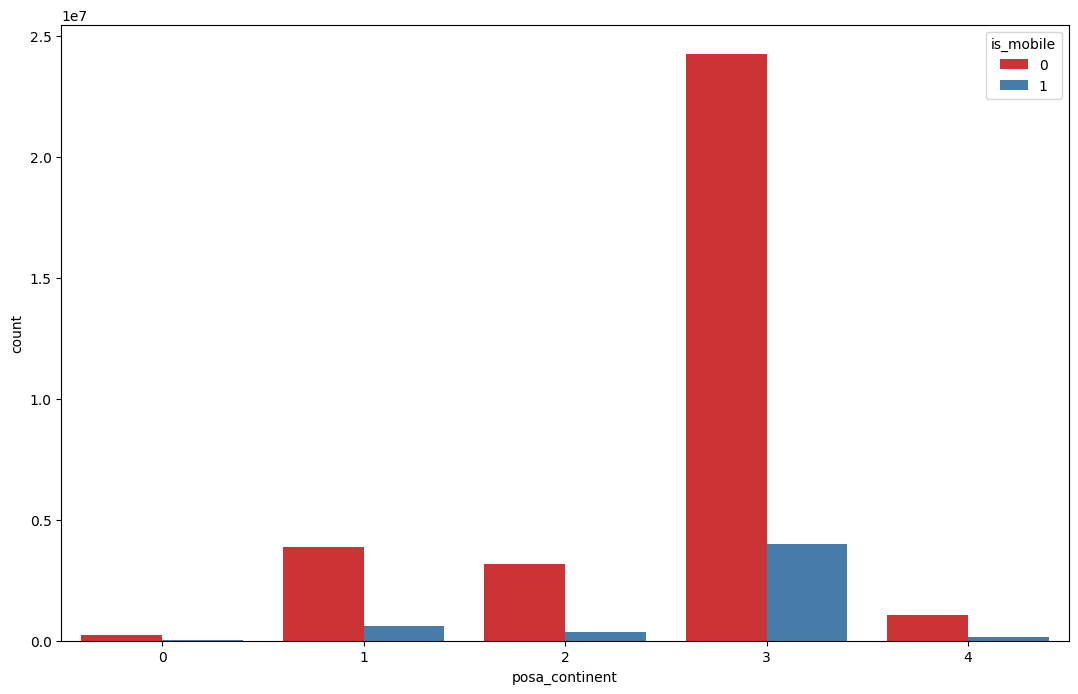

In [16]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 8)
sns.countplot(x='posa_continent', hue='is_mobile', data = df, palette="Set1")

**This code creates a count plot using Seaborn to display the distribution of user_location_country in the DataFrame df, sorted by user_location_country, with different colors representing is_mobile values. The plot size is set to 30x8 inches.**

**In this graph, we create another count plot for user_location_country, sorting the values, and use is_mobile as the hue to differentiate the counts based on mobile status.**

<Axes: xlabel='user_location_country', ylabel='count'>

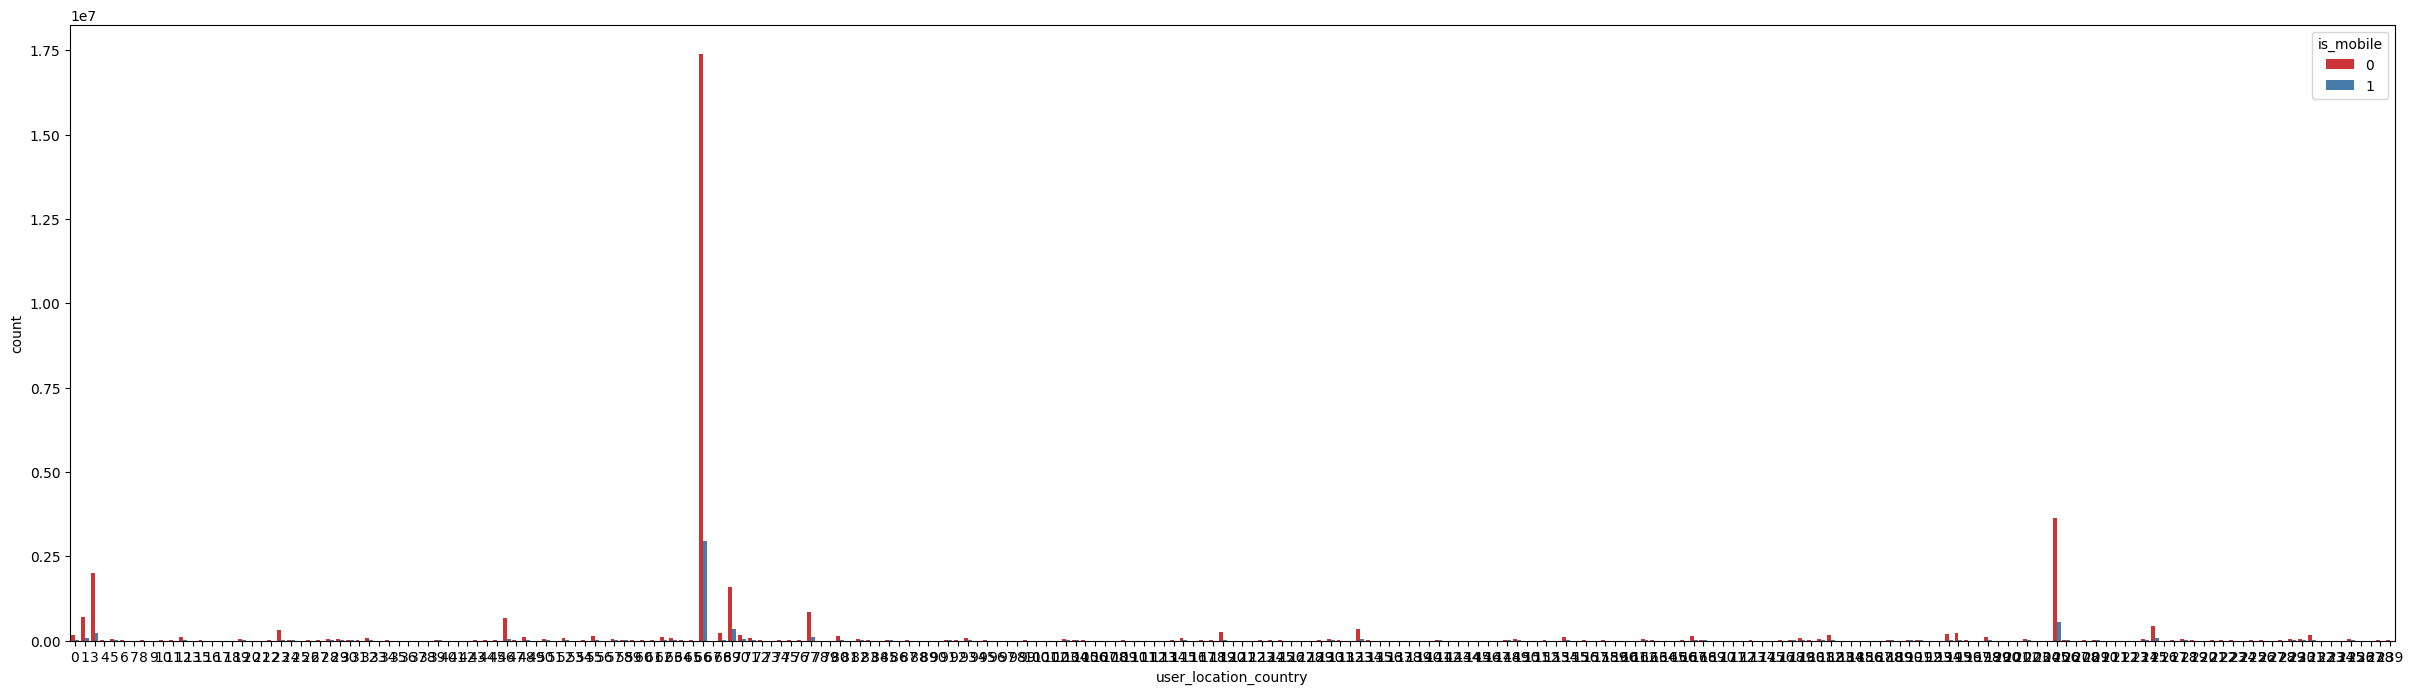

In [17]:
fig, ax = plt.subplots()
fig.set_size_inches(30, 8)
sns.countplot(x='user_location_country', hue='is_mobile', data = df, palette="Set1")

**This code creates a bar plot showing the count of each value in the hotel_cluster column of the DataFrame df, with the plot size set to 20x8 inches.**

**In this graph, we display the value counts for hotel_cluster using a bar plot.**

<Axes: xlabel='hotel_cluster'>

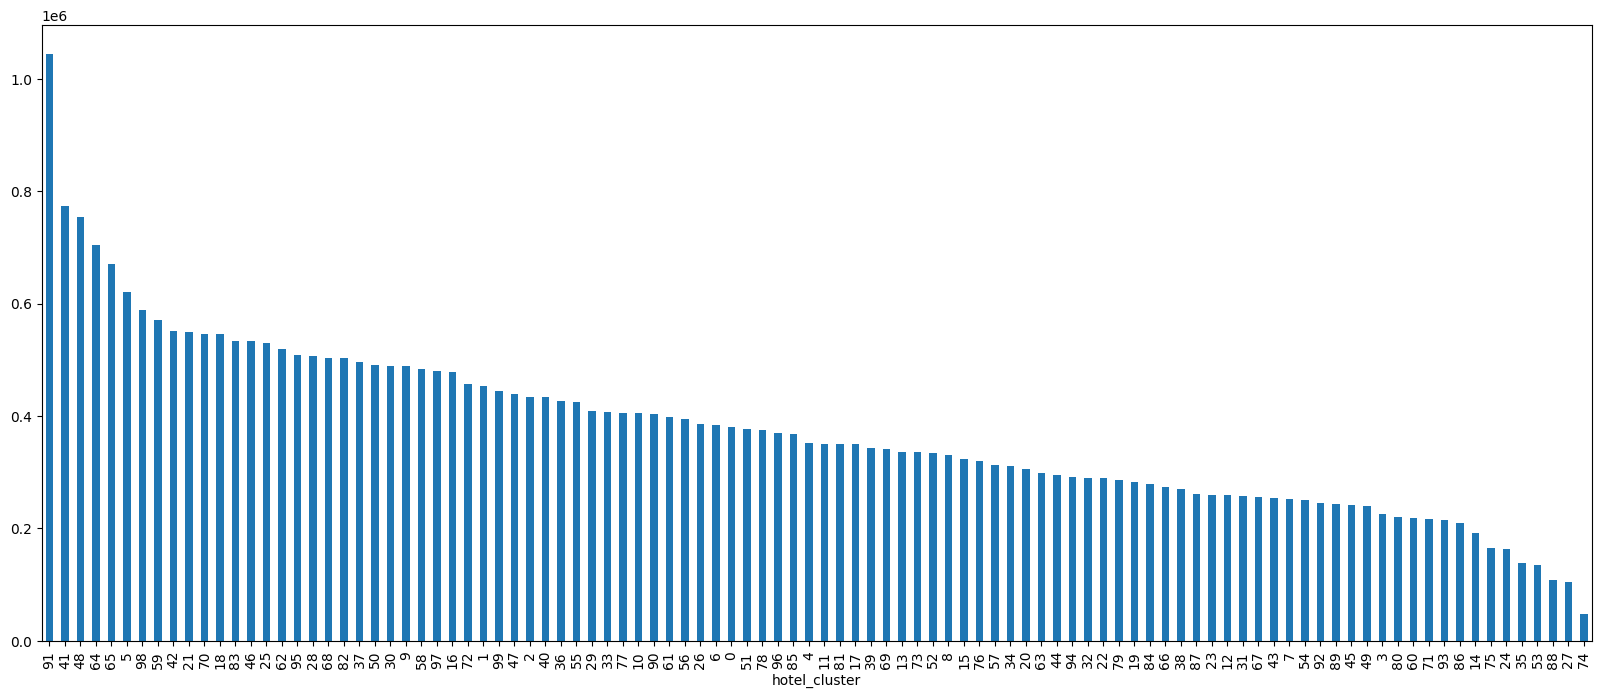

In [18]:
df['hotel_cluster'].value_counts().plot(kind='bar',figsize=(20,8))

**This code generates a count plot using Seaborn to display the distribution of the channel column in the DataFrame df, ordered from 0 to 9, with the plot size set to 20x8 inches and using the "Set1" color palette.**

**In this graph, we see the count plot for channel, with the order of categories specified as a list from 0 to 10.**

<Axes: xlabel='channel', ylabel='count'>

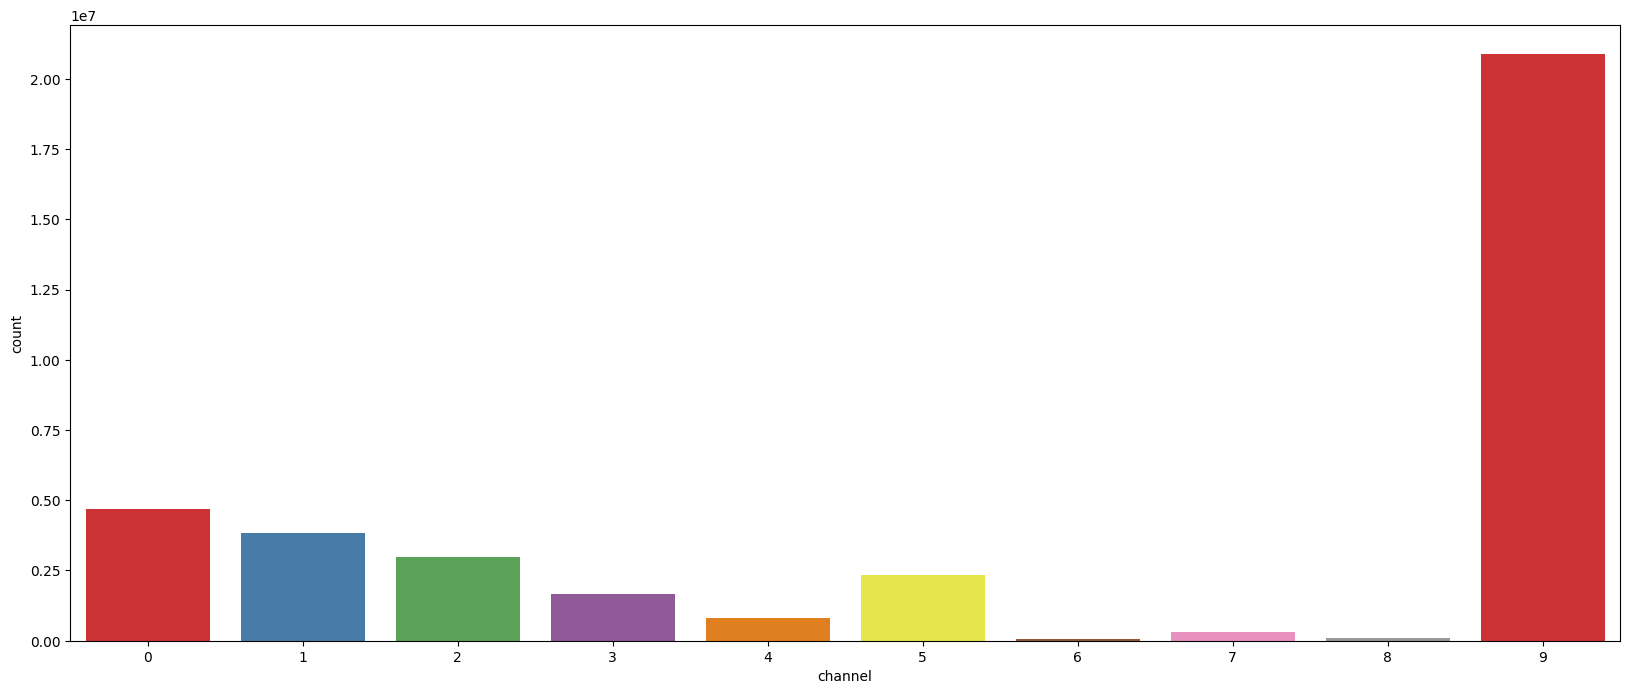

In [19]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 8)
sns.countplot(x='channel', order=list(range(0,10)), data=df, palette="Set1")

**df.head(5) returns the first 5 rows of the DataFrame df.**

In [12]:
df.head(5)

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,2014-08-11 07:46:59,2,3,66,348,48862,2234.2641,12,0,1,...,0,1,8250,1,0,3,2,50,628,1
1,2014-08-11 08:22:12,2,3,66,348,48862,2234.2641,12,0,1,...,0,1,8250,1,1,1,2,50,628,1
2,2014-08-11 08:24:33,2,3,66,348,48862,2234.2641,12,0,0,...,0,1,8250,1,0,1,2,50,628,1
3,2014-08-09 18:05:16,2,3,66,442,35390,913.1932,93,0,0,...,0,1,14984,1,0,1,2,50,1457,80
4,2014-08-09 18:08:18,2,3,66,442,35390,913.6259,93,0,0,...,0,1,14984,1,0,1,2,50,1457,21


# **Data Cleaning**

**Converts srch_ci, srch_co, and date_time columns to datetime format, coercing errors to NaT.**

**Creates a new column stay_duration representing the number of days between srch_co and srch_ci.**

**Creates a new column no_of_prior_days_booking representing the number of days between srch_ci and date_time.**

**Extracts the day, month, and year from srch_ci into new columns Cin_day, Cin_month, and Cin_year, respectively.**

**Drops the original date_time, srch_ci, and srch_co columns.**

In [7]:
df['srch_ci'] = pd.to_datetime(df['srch_ci'], infer_datetime_format=True, errors='coerce')
df['srch_co'] = pd.to_datetime(df['srch_co'], infer_datetime_format=True, errors='coerce')
df['date_time'] = pd.to_datetime(df['date_time'], infer_datetime_format=True, errors='coerce')

df['stay_duration'] = (df['srch_co'] - df['srch_ci']).dt.days
df['no_of_prior_days_booking'] = (df['srch_ci'] - df['date_time']).dt.days

df['Cin_day'] = df['srch_ci'].apply(lambda x: x.day)
df['Cin_month'] = df['srch_ci'].apply(lambda x: x.month)
df['Cin_year'] = df['srch_ci'].apply(lambda x: x.year)

df.drop(columns=['date_time', 'srch_ci', 'srch_co'], inplace=True)

df.head(5)

,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,...,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,stay_duration,no_of_prior_days_booking,Cin_day,Cin_month,Cin_year
0,2,3,66,348,48862,2234.2641,12,0,1,9,...,3,2,50,628,1,4.0,15.0,27.0,8.0,2014.0
1,2,3,66,348,48862,2234.2641,12,0,1,9,...,1,2,50,628,1,4.0,17.0,29.0,8.0,2014.0
2,2,3,66,348,48862,2234.2641,12,0,0,9,...,1,2,50,628,1,4.0,17.0,29.0,8.0,2014.0
3,2,3,66,442,35390,913.1932,93,0,0,3,...,1,2,50,1457,80,5.0,105.0,23.0,11.0,2014.0
4,2,3,66,442,35390,913.6259,93,0,0,3,...,1,2,50,1457,21,5.0,105.0,23.0,11.0,2014.0


**df.dropna(inplace=True) removes all rows from the DataFrame df that contain any missing values, and the changes are applied directly to the original DataFrame since inplace=True.**

In [8]:
df.dropna(inplace=True)

**df.isnull().sum() returns the total number of missing (null) values in each column of the DataFrame df. It provides a quick check to confirm if there are any remaining missing values after handling them.**

In [15]:
df.isnull().sum()

,0
site_name,0
posa_continent,0
user_location_country,0
user_location_region,0
user_location_city,0
orig_destination_distance,0
user_id,0
is_mobile,0
is_package,0
channel,0


**This code creates a heatmap of the correlation matrix for the DataFrame df, with annotations displaying correlation values, a color map of "coolwarm", and line widths of 1.0. The plot size is set to 20x20 inches.**

<Axes: >

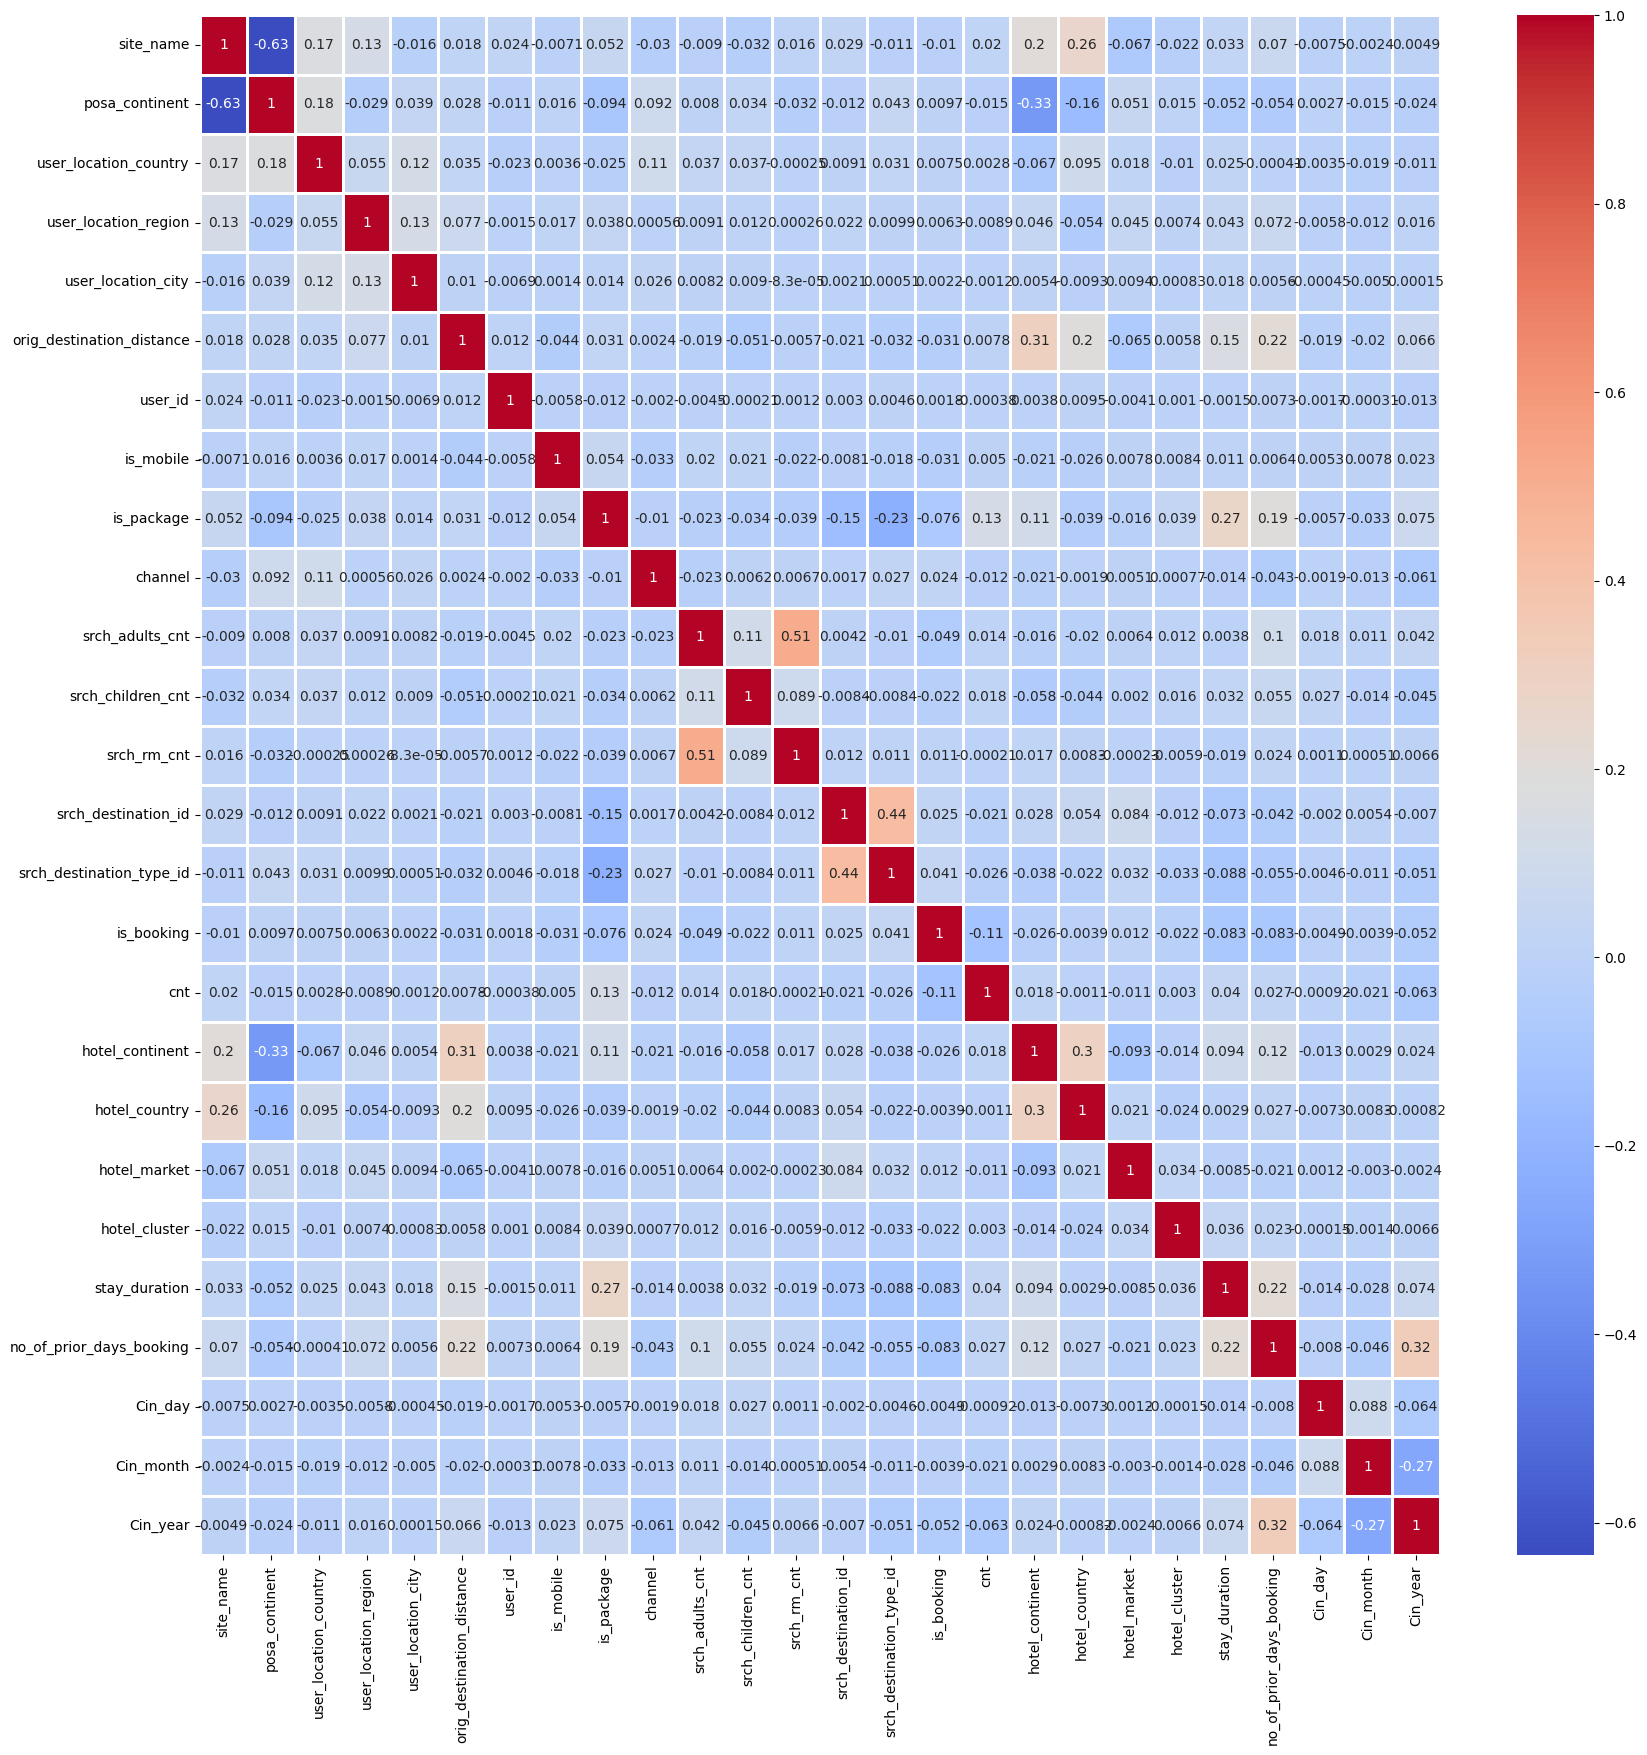

In [24]:
plt.figure(figsize=(20, 20))
sns.heatmap(df.corr(), annot = True, cmap="coolwarm", linewidths=1.0)

**df.columns returns the list of column names in the DataFrame df.**

In [16]:
df.columns

Index(['site_name', 'posa_continent', 'user_location_country',
       'user_location_region', 'user_location_city',
       'orig_destination_distance', 'user_id', 'is_mobile', 'is_package',
       'channel', 'srch_adults_cnt', 'srch_children_cnt', 'srch_rm_cnt',
       'srch_destination_id', 'srch_destination_type_id', 'is_booking', 'cnt',
       'hotel_continent', 'hotel_country', 'hotel_market', 'hotel_cluster',
       'stay_duration', 'no_of_prior_days_booking', 'Cin_day', 'Cin_month',
       'Cin_year'],
      dtype='object')

# **Model Building**

**This code selects a subset of columns from the DataFrame df to create feature matrix X and target variable y for a machine learning model:**

**X: Contains the predictor variables from the specified columns.**

**y: Contains the target variable hotel_cluster.**

In [9]:
X = df[['site_name', 'posa_continent', 'user_location_country',
       'user_location_region', 'user_location_city',
       'orig_destination_distance', 'user_id', 'is_mobile', 'is_package',
       'channel', 'srch_adults_cnt', 'srch_children_cnt', 'srch_rm_cnt',
       'srch_destination_id', 'srch_destination_type_id', 'is_booking', 'cnt',
       'hotel_continent', 'hotel_country', 'hotel_market',
       'stay_duration', 'no_of_prior_days_booking', 'Cin_day', 'Cin_month',
       'Cin_year']]

y = df[['hotel_cluster']]

**This code applies Min-Max scaling to the feature matrix X and the target variable y:**

**Scaler_X: Initializes a MinMaxScaler to scale X to a range between 0 and 1.**

**Scaler_y: Initializes a MinMaxScaler to scale y to a range between 0 and 1.**

**X = Scaler_X.fit_transform(X): Fits the scaler to X and transforms it.**

**y = Scaler_y.fit_transform(y): Fits the scaler to y and transforms it.**

**The set_output(transform="pandas") ensures that the output of the scaling is in a pandas DataFrame format.**

In [10]:
from sklearn.preprocessing import MinMaxScaler

Scaler_X = MinMaxScaler().set_output(transform = "pandas")

X = Scaler_X.fit_transform(X)

Scaler_y = MinMaxScaler().set_output(transform = "pandas")

y = Scaler_y.fit_transform(y)

**train_test_split: Splits the dataset into training and testing subsets, which is crucial for evaluating the performance of a machine learning model.**

**mean_squared_error: Calculates the Mean Squared Error (MSE), a common metric used to evaluate the performance of regression models by measuring the average squared difference between predicted and actual values.**

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

**This code splits the feature matrix X and target variable y into training and testing sets:**

**X_train and y_train: The training subset (80% of the data).**

**X_test and y_test: The testing subset (20% of the data).**

**The train_size=0.80 parameter specifies that 80% of the data should be used for training.**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.80)

**The code X_train.shape, X_test.shape, y_train.shape, y_test.shape will return the shapes of the training and testing datasets for both features and target variables. It provides the dimensions of the training and testing sets, helping you verify the split.**

In [13]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((30098559, 25), (7524640, 25), (30098559, 1), (7524640, 1))

**Import and Initialize: Import LinearRegression and initialize it with fit_intercept=False and n_jobs=-1 to use all available CPU cores.**

**Train Model: Fit the LinearRegression model using the training data (X_train and y_train).**

**Predict: Use the trained model to make predictions on the test data (X_test).**

**Evaluate: Calculate the Mean Squared Error (MSE) between the predicted values and actual values (y_test), and print the result.**

In [14]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression(fit_intercept = False, n_jobs = -1)

LR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Linear Regression: ", MSE)

Mean Squared Error For Linear Regression:  0.08483626266349566


**1: Random Forest Regressor Initialization: The function fit_random_forest_with_progress initializes a RandomForestRegressor with customizable parameters like n_estimators, max_depth, min_samples_leaf, min_samples_split, and class_weight.**

**2: Progress Bar: The tqdm progress bar tracks the fitting process, updating as each tree is added to the forest during the training loop.**

**3: Incremental Training: The for loop trains the RandomForestRegressor incrementally by increasing the number of estimators one at a time using the warm_start=True option, allowing the model to add trees without losing previously trained trees.**

**4: Model Fitting: The model is trained with the input data X_train and y_train inside the loop, fitting one tree per iteration until all estimators are added.**

**5: Model Evaluation: After training, the model makes predictions on X_test, and the Mean Squared Error (MSE) between the predictions and actual values (y_test) is computed and printed.**

In [15]:
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm


def fit_random_forest_with_progress(X_train, y_train, n_estimators=10, max_depth=3, min_samples_leaf=5, min_samples_split=5, class_weight='balanced'):
    RFR = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        n_jobs=1,
        warm_start=True,
        verbose=0
    )

    pbar = tqdm(total=n_estimators, desc="Fitting Random Forest", unit="tree")

    for i in range(n_estimators):
        RFR.n_estimators = i + 1
        RFR.fit(X_train, y_train)
        pbar.update(1)

    pbar.close()
    return RFR

RFR = fit_random_forest_with_progress(X_train, y_train)

y_pred = RFR.predict(X_test)

MSE = mean_squared_error(y_test, y_pred)
print("Mean Squared Error For Random Forest Regressor: ", MSE)

Fitting Random Forest: 100%|██████████| 10/10 [11:02<00:00, 66.27s/tree]


Mean Squared Error For Random Forest Regressor:  0.08408802072185279


**1: Decision Tree Initialization: The fit_decision_tree_with_progress function initializes a DecisionTreeRegressor with customizable parameters like max_depth, min_samples_split, and min_samples_leaf.**

**2: Progress Bar with tqdm: A progress bar is set up using tqdm to visually track the progress of the decision tree fitting process. It shows progress in percentage and is updated as the model is being fit.**

**3: Model Fitting: The DTR.fit(X_train, y_train) line trains the DecisionTreeRegressor on the training dataset, which happens while the progress bar runs alongside.**

**4: Artificial Delay for Progress Bar: A for loop with a sleep(0.05) function is used to artificially update the progress bar to simulate progress over time, even though the decision tree fitting is quick and typically wouldn't need a delay.**

**5: Model Evaluation: After training, the model makes predictions on X_test, and the Mean Squared Error (MSE) between the predictions and actual values (y_test) is computed and printed.**

In [17]:
from sklearn.tree import DecisionTreeRegressor
from tqdm import tqdm
from time import sleep

def fit_decision_tree_with_progress(X_train, y_train, X_test, max_depth=5, min_samples_split=5, min_samples_leaf=5):
    DTR = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf
    )

    with tqdm(total=100, desc="Fitting Decision Tree", unit="%", ncols=100) as pbar:
        DTR.fit(X_train, y_train)
        for _ in range(100):
            sleep(0.05)
            pbar.update(1)

    return DTR

DTR = fit_decision_tree_with_progress(X_train, y_train, X_test)

y_pred = DTR.predict(X_test)

MSE = mean_squared_error(y_test, y_pred)
print("Mean Squared Error For Decision Tree Regressor: ", MSE)

Fitting Decision Tree: 100%|███████████████████████████████████████| 100/100 [02:43<00:00,  1.64s/%]


Mean Squared Error For Decision Tree Regressor:  0.08332018573818582


# **Conclusion:**

**Mean Squared Error For Decision Tree Regressor:  0.08332**

**Mean Squared Error For Random Forest Regressor:  0.08408**

**Mean Squared Error For Linear Regression:  0.08483**

**We evaluated multiple models, and the Random Forest Regressor (RFR) demonstrated the best performance with a Mean Squared Error of 0.0840.**

**Despite its slightly higher error compared to the Decision Tree Regressor (0.0833), RFR is noted for its robustness and overall accuracy.**

**Therefore, RFR is selected as the model for future use.**

# **Save Model**

* **Serializes and saves the trained Decision Tree Regression model ("DTR") for future reuse without retraining.**
* **Persists the feature scaler ("Scaler_X") to ensure consistent input preprocessing during inference.**
* **Stores the target scaler ("Scaler_y") so predictions can be correctly inverse-transformed back to original scale.**

In [18]:
import pickle

with open("Finalized-Model.pickle", "wb") as file:
    pickle.dump(DTR, file)

with open("Scaler_X.pickle", "wb") as file:
    pickle.dump(Scaler_X, file)

with open("Scaler_y.pickle", "wb") as file:
    pickle.dump(Scaler_y, file)